In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df = df.rename(columns={
    "Pregnancies": "patient_visits",
    "Glucose": "glucose_level",
    "BloodPressure": "blood_pressure",
    "SkinThickness": "skin_thickness",
    "Insulin": "insulin_level",
    "BMI": "bmi",
    "DiabetesPedigreeFunction": "risk_score",
    "Age": "patient_age",
    "Outcome": "disease_outcome"
})

In [4]:
# Replace zero values with NaN (real-world clinical cleaning logic)
cols_to_clean = ["glucose_level","blood_pressure","skin_thickness","insulin_level","bmi"]

for col in cols_to_clean:
    df[col] = df[col].replace(0, np.nan)

# Fill missing values with median (clinical standard practice simulation)
for col in cols_to_clean:
    df[col].fillna(df[col].median(), inplace=True)

df.isnull().sum()

/tmp/ipykernel_13611/2427548814.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,0
patient_visits,0
glucose_level,0
blood_pressure,0
skin_thickness,0
insulin_level,0
bmi,0
risk_score,0
patient_age,0
disease_outcome,0


In [5]:
fact_patient = df.copy()
fact_patient["patient_id"] = range(1000, 1000 + len(df))

fact_patient.head()

,patient_visits,glucose_level,blood_pressure,skin_thickness,insulin_level,bmi,risk_score,patient_age,disease_outcome,patient_id
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1000
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,1001
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,1002
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,1003
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1004


In [6]:
dim_age = fact_patient[["patient_id", "patient_age"]].copy()

def age_group(age):
    if age < 30:
        return "Young"
    elif age < 50:
        return "Middle"
    else:
        return "Senior"

dim_age["age_group"] = dim_age["patient_age"].apply(age_group)

dim_age.head()

,patient_id,patient_age,age_group
0,1000,50,Senior
1,1001,31,Middle
2,1002,32,Middle
3,1003,21,Young
4,1004,33,Middle


In [7]:
kpi_total_patients = len(fact_patient)
kpi_disease_rate = fact_patient["disease_outcome"].mean() * 100
kpi_avg_glucose = fact_patient["glucose_level"].mean()

print("Total Patients:", kpi_total_patients)
print("Disease Rate %:", kpi_disease_rate)
print("Avg Glucose Level:", kpi_avg_glucose)

Total Patients: 768
Disease Rate %: 34.89583333333333
Avg Glucose Level: 121.65625


In [8]:
age_analysis = fact_patient.groupby("patient_age").agg({
    "glucose_level": "mean",
    "bmi": "mean",
    "disease_outcome": "mean"
}).reset_index()

age_analysis.head()

,patient_age,glucose_level,bmi,disease_outcome
0,21,110.174603,29.355556,0.079365
1,22,111.458333,30.406944,0.152778
2,23,111.578947,31.502632,0.184211
3,24,117.891304,33.271739,0.173913
4,25,110.083333,32.616667,0.291667


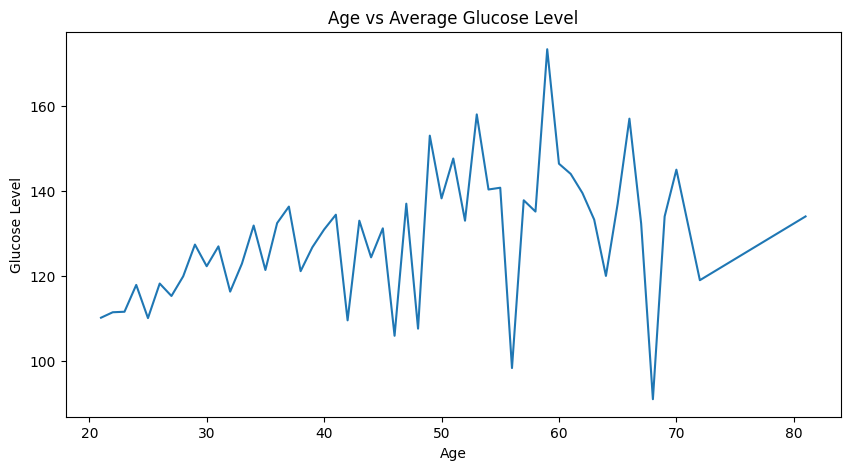

In [9]:
plt.figure(figsize=(10,5))
plt.plot(age_analysis["patient_age"], age_analysis["glucose_level"])
plt.title("Age vs Average Glucose Level")
plt.xlabel("Age")
plt.ylabel("Glucose Level")
plt.show()

In [10]:
fact_patient.to_csv("fact_patient_table.csv", index=False)
dim_age.to_csv("dim_age_table.csv", index=False)
age_analysis.to_csv("kpi_age_analysis.csv", index=False)